In [23]:
import matplotlib.pyplot as plt
import matplotlib as mpl
import platform

# 시스템에 따라 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'  # 윈도우 기본 한글 폰트
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'    # 맥 기본 한글 폰트
else:
    plt.rcParams['font.family'] = 'NanumGothic'     # 리눅스 또는 Google Colab 등

# 마이너스 기호 깨짐 방지
mpl.rcParams['axes.unicode_minus'] = False

In [1]:
import pandas as pd

# 파일 경로에 맞게 수정하세요
file_path = 'C:/Users/USER/Desktop/data/cleaned/inventory_items_EDA.csv'
df = pd.read_csv(file_path)

# 상위 5개 행 미리보기
df.head()

,id,product_id,created_at,sold_at,cost,product_category,product_name,product_brand,product_retail_price,product_department,product_sku,product_distribution_center_id,created_year,created_month,created_day,created_weekday
0,67971,13844,2022-07-02 07:09:20+00:00,2022-07-24 06:33:20+00:00,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7,2022.0,7.0,2.0,Saturday
1,67972,13844,2023-12-20 03:28:00+00:00,NaN,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7,2023.0,12.0,20.0,Wednesday
2,67973,13844,2023-06-04 02:53:00+00:00,NaN,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7,2023.0,6.0,4.0,Sunday
3,72863,13844,2021-10-16 22:58:52+00:00,2021-11-22 02:19:52+00:00,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7,2021.0,10.0,16.0,Saturday
4,72864,13844,2021-08-07 16:33:00+00:00,NaN,2.76804,Accessories,(ONE) 1 Satin Headband,Funny Girl Designs,6.99,Women,2A3E953A5E3D81E67945BCE5519F84C8,7,2021.0,8.0,7.0,Saturday


In [5]:
### 컬럼 별 기본 정보
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 490705 entries, 0 to 490704
Data columns (total 16 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   id                              490705 non-null  int64  
 1   product_id                      490705 non-null  int64  
 2   created_at                      486300 non-null  object 
 3   sold_at                         181759 non-null  object 
 4   cost                            490705 non-null  float64
 5   product_category                490705 non-null  object 
 6   product_name                    490705 non-null  object 
 7   product_brand                   490705 non-null  object 
 8   product_retail_price            490705 non-null  float64
 9   product_department              490705 non-null  object 
 10  product_sku                     490705 non-null  object 
 11  product_distribution_center_id  490705 non-null  int64  
 12  created_year    

In [7]:
###수치형 / 범주형 요약 통계

# 수치형 변수 요약
df.describe()

# 범주형 변수 요약
df.describe(include='object')

,created_at,sold_at,product_category,product_name,product_brand,product_department,product_sku,created_weekday
count,486300,181759,490705,490705,490705,490705,490705,486300
unique,458934,181526,26,27237,2753,2,29046,7
top,2020-09-30 15:54:00+00:00,2022-12-23 07:25:54+00:00,Intimates,Wrangler Men's Premium Performance Cowboy Cut ...,Allegra K,Women,6B45CF467A9C88001159A826E92C7437,Friday
freq,6,2,36353,161,17019,245625,58,69628


### 시간 흐름에 따른 트랜드 분석

In [17]:
# sold_at이 datetime이 아니라면 먼저 변환
df['sold_at'] = pd.to_datetime(df['sold_at'], format='ISO8601', utc=True)

# sold_at에서 연, 월, 일, 요일 파생 변수 추가
df['sold_year'] = df['sold_at'].dt.year
df['sold_month'] = df['sold_at'].dt.month
df['sold_day'] = df['sold_at'].dt.day
df['sold_weekday'] = df['sold_at'].dt.day_name()

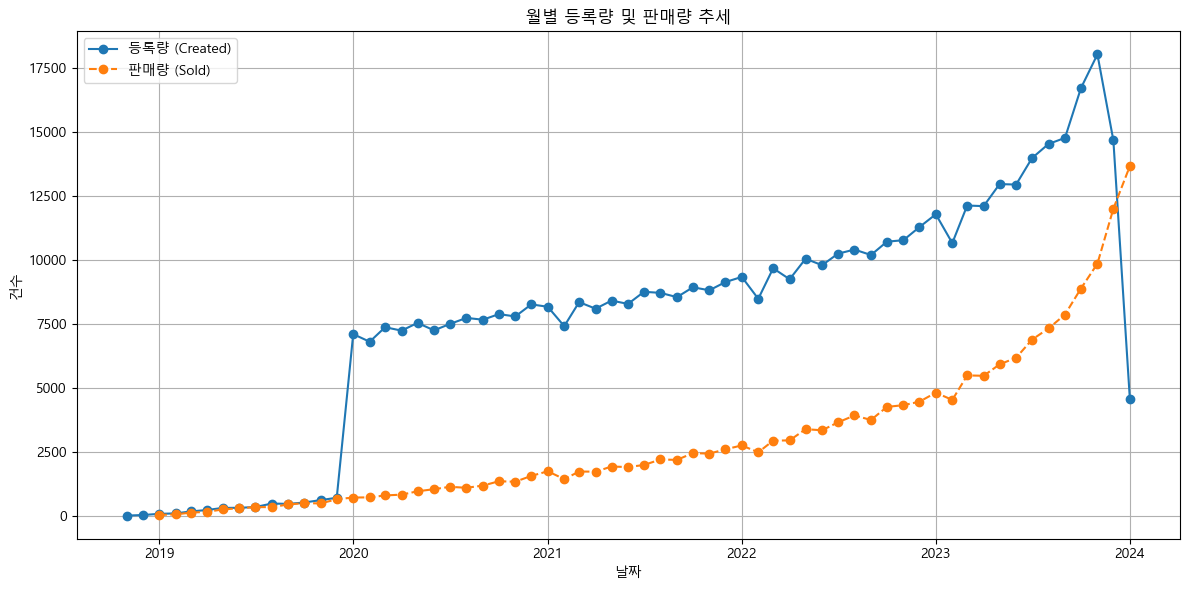

In [25]:
import matplotlib.pyplot as plt

# 월별 등록량
created_trend = df.groupby(['created_year', 'created_month']).size()

# 월별 판매량
sold_trend = df.groupby(['sold_year', 'sold_month']).size()

# 인덱스(datetime 변환 위해 int로 변환 후 날짜 문자열 생성)
created_trend.index = pd.to_datetime(
    created_trend.index.map(lambda x: f"{int(x[0])}-{int(x[1]):02d}")
)

sold_trend.index = pd.to_datetime(
    sold_trend.index.map(lambda x: f"{int(x[0])}-{int(x[1]):02d}")
)

# 시각화
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(created_trend.index, created_trend.values, label='등록량 (Created)', marker='o')
plt.plot(sold_trend.index, sold_trend.values, label='판매량 (Sold)', marker='o', linestyle='--')
plt.title('월별 등록량 및 판매량 추세')
plt.xlabel('날짜')
plt.ylabel('건수')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

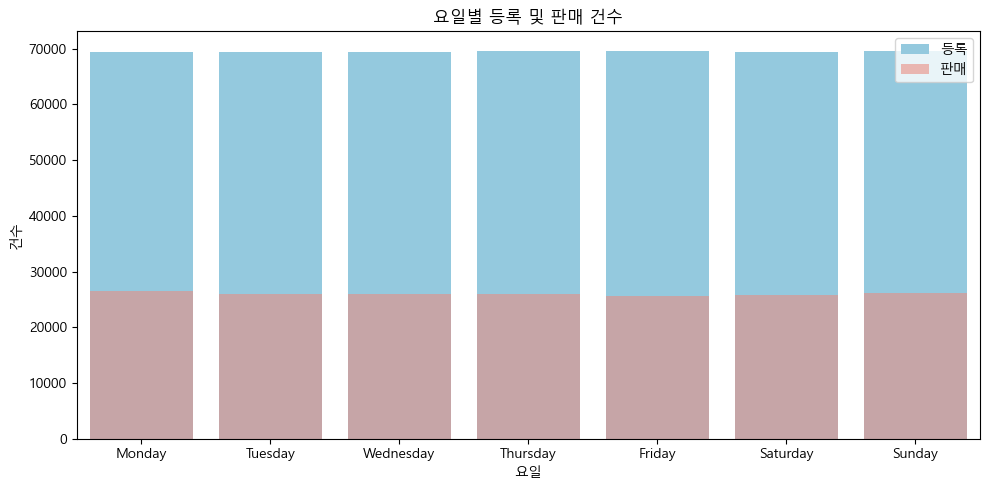

In [27]:
import seaborn as sns

# 요일 정렬을 위해 Categorical로 변환
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
df['created_weekday'] = pd.Categorical(df['created_weekday'], categories=weekday_order, ordered=True)
df['sold_weekday'] = pd.Categorical(df['sold_weekday'], categories=weekday_order, ordered=True)

# 요일별 건수 집계
created_weekday_counts = df['created_weekday'].value_counts().sort_index()
sold_weekday_counts = df['sold_weekday'].value_counts().sort_index()

# 시각화
plt.figure(figsize=(10, 5))
sns.barplot(x=created_weekday_counts.index, y=created_weekday_counts.values, color='skyblue', label='등록')
sns.barplot(x=sold_weekday_counts.index, y=sold_weekday_counts.values, color='salmon', alpha=0.6, label='판매')
plt.title('요일별 등록 및 판매 건수')
plt.xlabel('요일')
plt.ylabel('건수')
plt.legend()
plt.tight_layout()
plt.show()

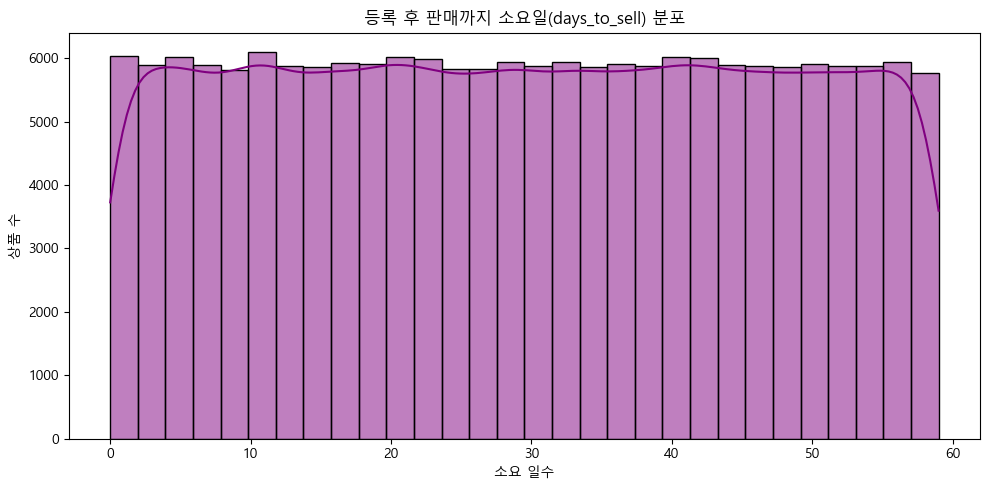

In [29]:
# 회전일수 계산 (판매일 - 등록일)
df['days_to_sell'] = (df['sold_at'] - df['created_at']).dt.days

# 분포 시각화
plt.figure(figsize=(10, 5))
sns.histplot(df['days_to_sell'], bins=30, kde=True, color='purple')
plt.title('등록 후 판매까지 소요일(days_to_sell) 분포')
plt.xlabel('소요 일수')
plt.ylabel('상품 수')
plt.tight_layout()
plt.show()

In [106]:
#월별 등록/판매량 추세 세분화

# 1) created_year, created_month 유효한 행만 필터링
valid_date_mask = (df['created_year'] > 0) & (df['created_month'] > 0)
df_valid = df[valid_date_mask].copy()

# 2) created_ym 생성
df_valid['created_ym'] = pd.to_datetime(
    df_valid['created_year'].astype(int).astype(str) + '-' +
    df_valid['created_month'].astype(int).astype(str).str.zfill(2)
)

# 3) 등록 월별 + 카테고리별 집계
monthly_created = df_valid.groupby(['created_ym', 'product_category']).size().reset_index(name='등록 수')

# 4) sold_at 안전하게 datetime 변환 및 필터링
df['sold_at'] = pd.to_datetime(df['sold_at'], errors='coerce')
df_sold_valid = df[df['sold_at'].notna()].copy()
df_sold_valid['sold_ym'] = df_sold_valid['sold_at'].dt.to_period('M').dt.to_timestamp()

# 5) 판매 월별 + 카테고리별 집계
monthly_sold = df_sold_valid.groupby(['sold_ym', 'product_category']).size().reset_index(name='판매 수')

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_33312\2214128229.py:19: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  df_sold_valid['sold_ym'] = df_sold_valid['sold_at'].dt.to_period('M').dt.to_timestamp()


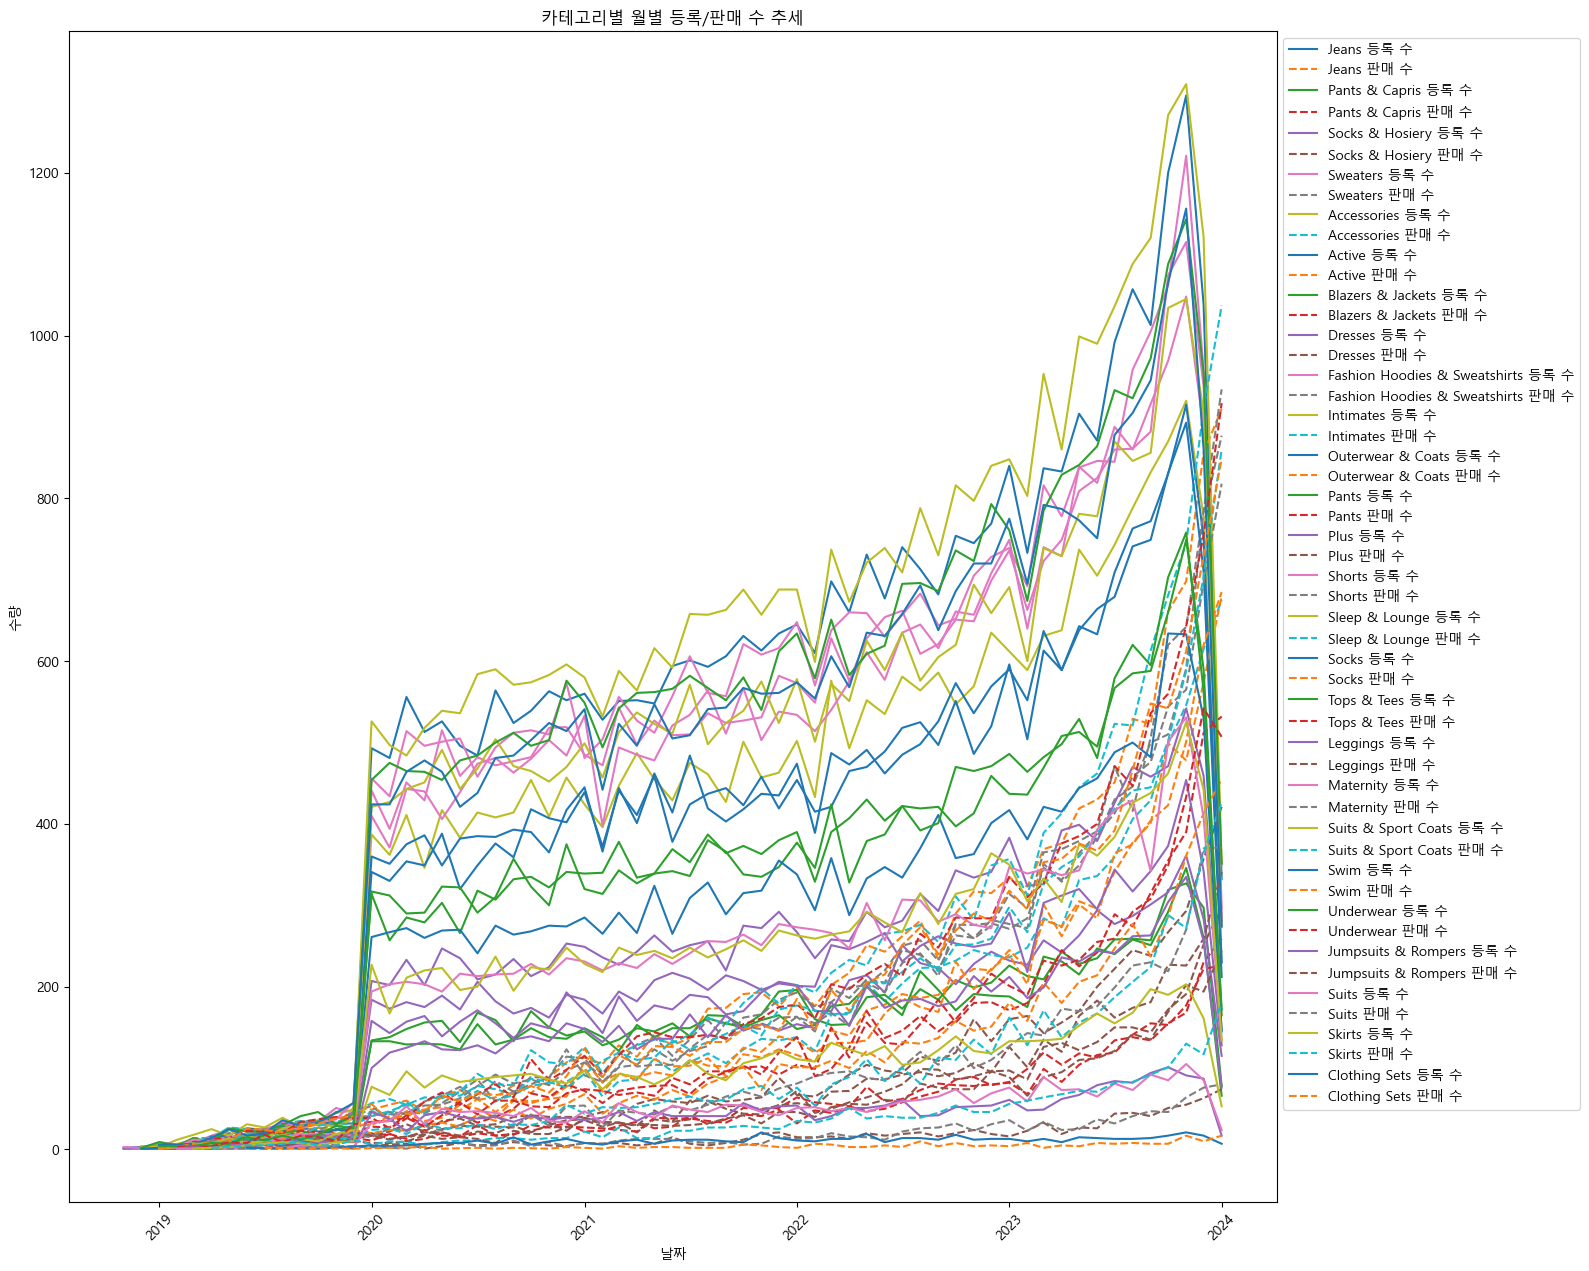

In [112]:
plt.figure(figsize=(16, 13))

categories = monthly_created['product_category'].unique()

for cat in categories:
    plt.plot(
        monthly_created[monthly_created['product_category'] == cat]['created_ym'],
        monthly_created[monthly_created['product_category'] == cat]['등록 수'],
        label=f'{cat} 등록 수'
    )
    plt.plot(
        monthly_sold[monthly_sold['product_category'] == cat]['sold_ym'],
        monthly_sold[monthly_sold['product_category'] == cat]['판매 수'],
        linestyle='--',
        label=f'{cat} 판매 수'
    )

plt.title('카테고리별 월별 등록/판매 수 추세')
plt.xlabel('날짜')
plt.ylabel('수량')
plt.legend(loc='upper left', bbox_to_anchor=(1,1))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

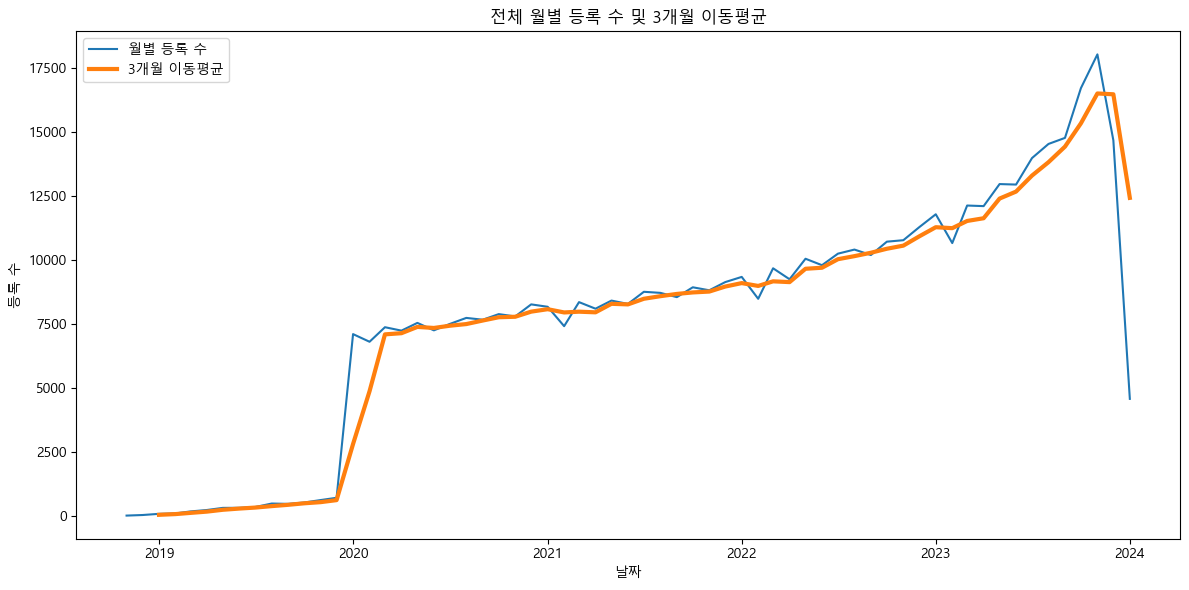

In [116]:
def moving_average(df, window=3):
    return df.rolling(window=window, on='date')['value'].mean()

# 예시: 전체 등록 월별 데이터 이동평균
monthly_total_created = df_valid.groupby('created_ym').size().reset_index(name='등록 수')
monthly_total_created['이동평균_3개월'] = monthly_total_created['등록 수'].rolling(window=3).mean()

plt.figure(figsize=(12, 6))
plt.plot(monthly_total_created['created_ym'], monthly_total_created['등록 수'], label='월별 등록 수')
plt.plot(monthly_total_created['created_ym'], monthly_total_created['이동평균_3개월'], label='3개월 이동평균', linewidth=3)
plt.title('전체 월별 등록 수 및 3개월 이동평균')
plt.xlabel('날짜')
plt.ylabel('등록 수')
plt.legend()
plt.tight_layout()
plt.show()

### 가격분석

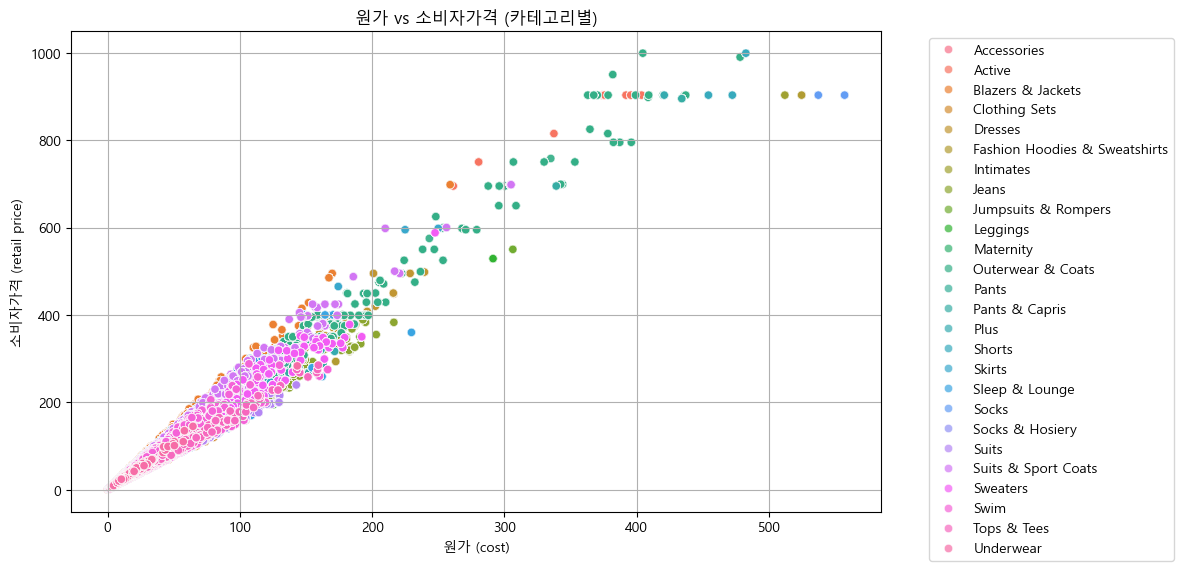

In [33]:
plt.figure(figsize=(12, 6))
sns.scatterplot(
    data=df,
    x='cost',
    y='product_retail_price',
    hue='product_category',
    alpha=0.7
)
plt.title('원가 vs 소비자가격 (카테고리별)')
plt.xlabel('원가 (cost)')
plt.ylabel('소비자가격 (retail price)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

In [35]:
# 마진 및 마진율 계산을 위한 파생변수 생성
df['profit'] = df['product_retail_price'] - df['cost']
df['profit_margin_rate'] = df['profit'] / df['product_retail_price']


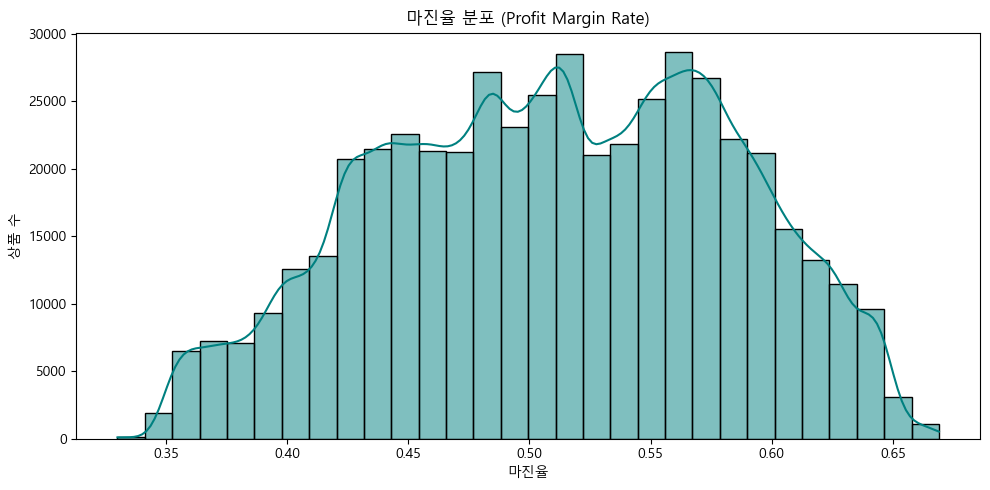

In [37]:
plt.figure(figsize=(10, 5))
sns.histplot(df['profit_margin_rate'], bins=30, kde=True, color='teal')
plt.title('마진율 분포 (Profit Margin Rate)')
plt.xlabel('마진율')
plt.ylabel('상품 수')
plt.tight_layout()
plt.show()

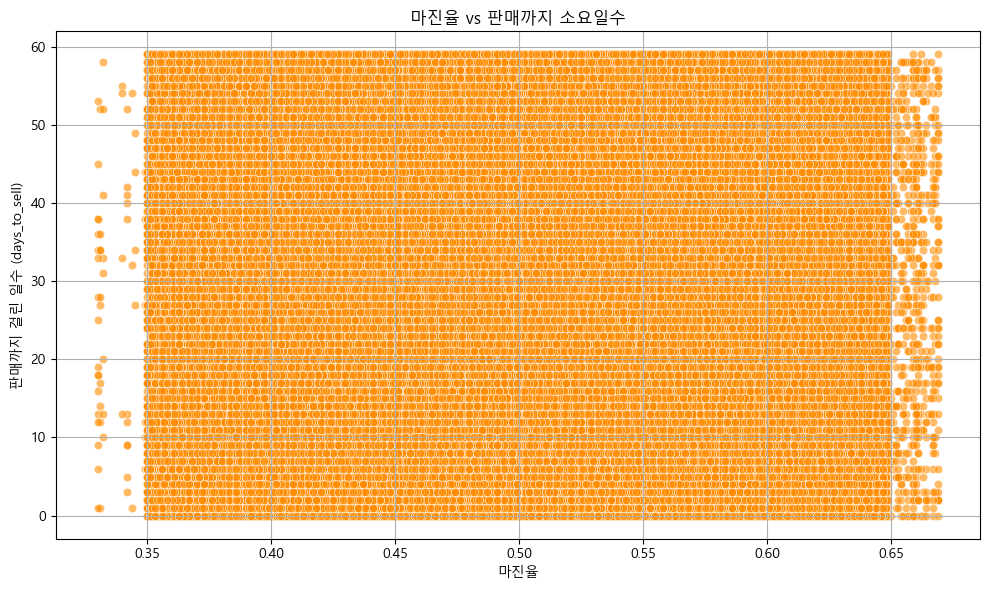

In [39]:
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=df,
    x='profit_margin_rate',
    y='days_to_sell',
    alpha=0.6,
    color='darkorange'
)
plt.title('마진율 vs 판매까지 소요일수')
plt.xlabel('마진율')
plt.ylabel('판매까지 걸린 일수 (days_to_sell)')
plt.grid(True)
plt.tight_layout()
plt.show()

### 카테고리/브랜드/부서별 분석

In [42]:
# 등록 수량
created_counts = df['product_category'].value_counts().reset_index()
created_counts.columns = ['product_category', '등록 수량']

# 판매 수량
sold_counts = df[~df['sold_at'].isna()]['product_category'].value_counts().reset_index()
sold_counts.columns = ['product_category', '판매 수량']

# 병합
category_summary = pd.merge(created_counts, sold_counts, on='product_category', how='left').fillna(0)
category_summary = category_summary.sort_values(by='판매 수량', ascending=False)
category_summary['판매율'] = category_summary['판매 수량'] / category_summary['등록 수량']

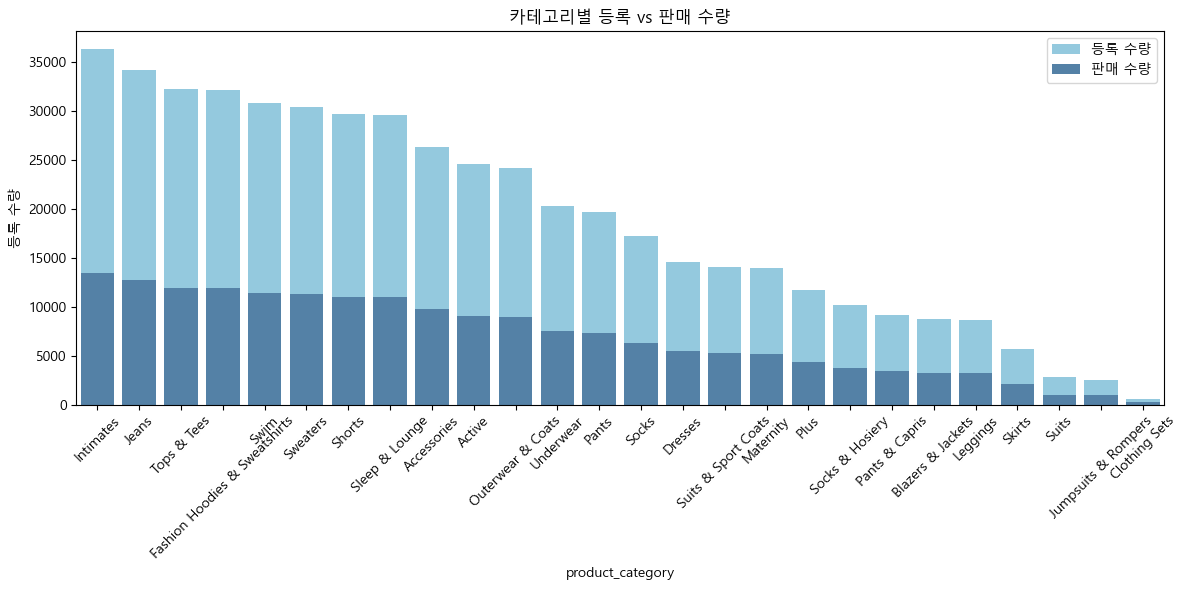

In [44]:
plt.figure(figsize=(12, 6))
sns.barplot(data=category_summary, x='product_category', y='등록 수량', color='skyblue', label='등록 수량')
sns.barplot(data=category_summary, x='product_category', y='판매 수량', color='steelblue', label='판매 수량')
plt.title('카테고리별 등록 vs 판매 수량')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [46]:
category_metrics = df.groupby('product_category').agg({
    'profit_margin_rate': 'mean',
    'days_to_sell': 'mean',
    'id': 'count'
}).rename(columns={
    'profit_margin_rate': '평균 마진율',
    'days_to_sell': '평균 회전일수',
    'id': '상품 수'
}).reset_index()

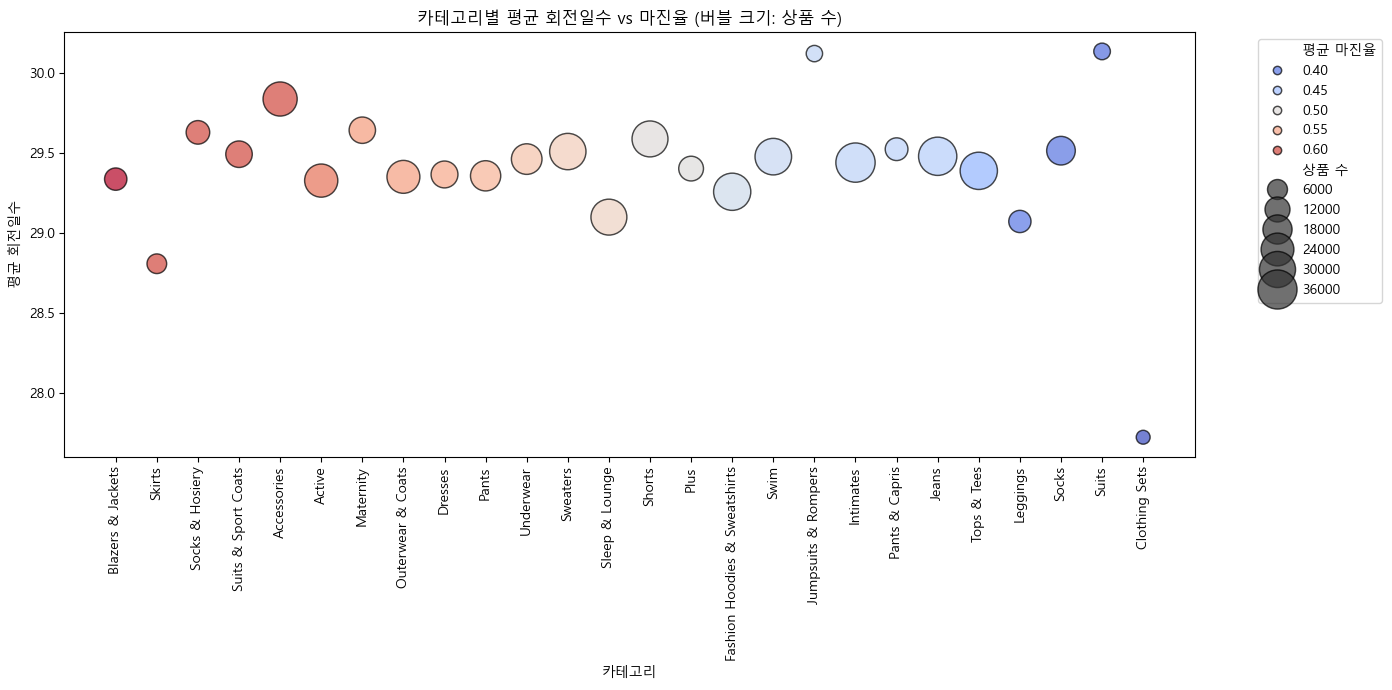

In [52]:
# 정렬: 평균 마진율 높은 순
category_metrics_sorted = category_metrics.sort_values(by='평균 마진율', ascending=False)

plt.figure(figsize=(14, 7))
sns.scatterplot(
    data=category_metrics_sorted,
    x='product_category',
    y='평균 회전일수',
    size='상품 수',
    hue='평균 마진율',
    palette='coolwarm',
    sizes=(100, 800),
    alpha=0.7,
    edgecolor='black',
    legend='brief'
)

plt.xticks(rotation=90)
plt.title('카테고리별 평균 회전일수 vs 마진율 (버블 크기: 상품 수)')
plt.xlabel('카테고리')
plt.ylabel('평균 회전일수')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [54]:
top_brands = df['product_brand'].value_counts().head(10).index
brand_summary = df[df['product_brand'].isin(top_brands)].groupby('product_brand').agg({
    'id': 'count',
    'profit_margin_rate': 'mean',
    'days_to_sell': 'mean'
}).rename(columns={
    'id': '등록 수',
    'profit_margin_rate': '평균 마진율',
    'days_to_sell': '평균 회전일수'
}).sort_values(by='등록 수', ascending=False)

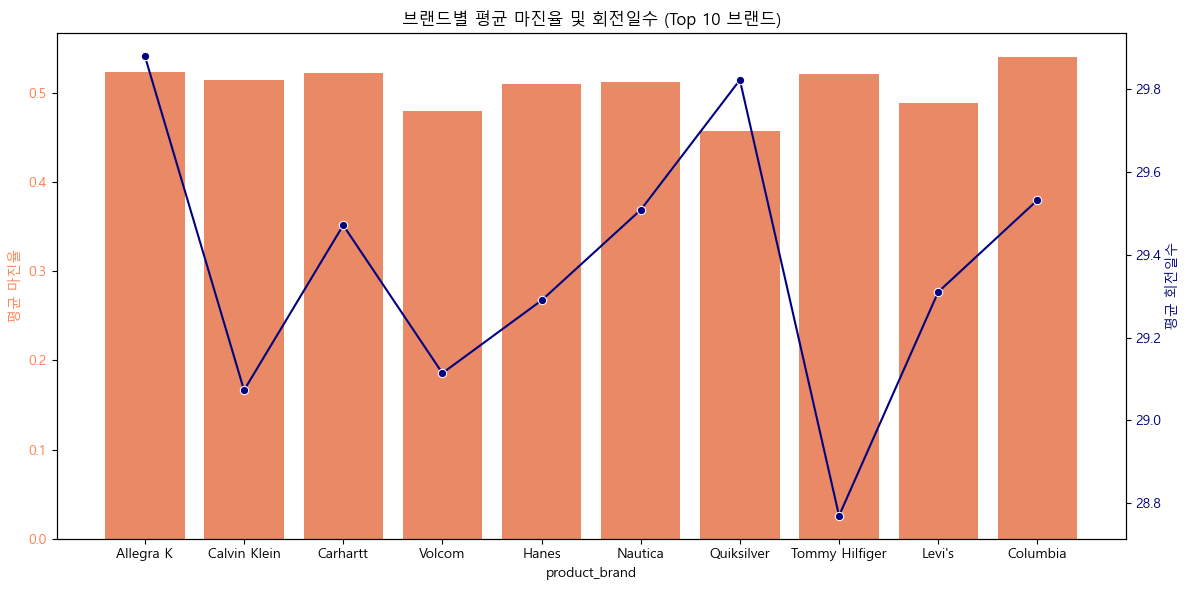

In [56]:
fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=brand_summary.reset_index(), x='product_brand', y='평균 마진율', ax=ax1, color='coral')
ax1.set_ylabel('평균 마진율', color='coral')
ax1.tick_params(axis='y', labelcolor='coral')

# 두 번째 y축
ax2 = ax1.twinx()
sns.lineplot(data=brand_summary.reset_index(), x='product_brand', y='평균 회전일수', ax=ax2, color='navy', marker='o')
ax2.set_ylabel('평균 회전일수', color='navy')
ax2.tick_params(axis='y', labelcolor='navy')

plt.title('브랜드별 평균 마진율 및 회전일수 (Top 10 브랜드)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 파생변수 생성 및 통합 분석

In [61]:
df['is_sold'] = ~df['sold_at'].isna()

In [63]:
df['profit'] = df['product_retail_price'] - df['cost']
df['profit_margin_rate'] = df['profit'] / df['product_retail_price']

In [70]:
# 상품 등록 시점의 시즌
def assign_season(month):
    if month in [12, 1, 2]:
        return '겨울'
    elif month in [3, 4, 5]:
        return '봄'
    elif month in [6, 7, 8]:
        return '여름'
    else:
        return '가을'

df['created_season'] = df['created_month'].apply(assign_season)

In [72]:
# 소매가 기준 상위 20% 고가 상품 여부

threshold = df['product_retail_price'].quantile(0.8)
df['is_high_price'] = df['product_retail_price'] >= threshold

In [74]:
#회전율 7일 미만의 빠른 판매 여부
df['is_fast_sold'] = df['days_to_sell'] <= 7

In [76]:
season_summary = df.groupby('created_season').agg({
    'id': 'count',
    'is_sold': 'sum',
    'profit_margin_rate': 'mean',
    'days_to_sell': 'mean'
}).rename(columns={
    'id': '등록 수',
    'is_sold': '판매 수',
    'profit_margin_rate': '평균 마진율',
    'days_to_sell': '평균 회전일수'
}).reset_index()

print(season_summary)

  created_season    등록 수   판매 수    평균 마진율    평균 회전일수
0             가을  136882  60831  0.510174  30.500744
1             겨울  118608  39538  0.510299  26.607567
2              봄  113905  36929  0.510477  30.032197
3             여름  121310  44461  0.510450  30.093273


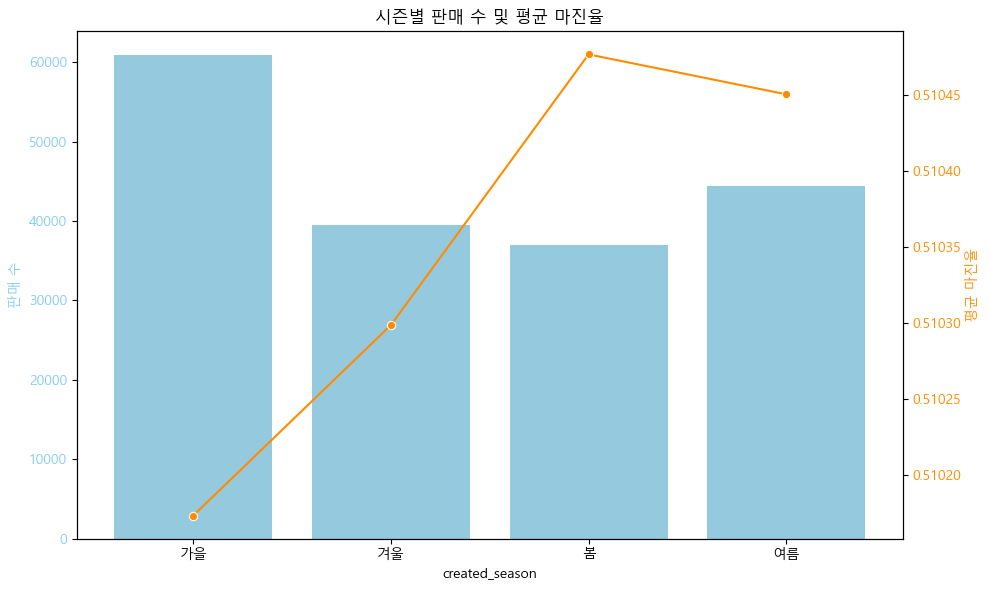

In [78]:
fig, ax1 = plt.subplots(figsize=(10, 6))

sns.barplot(data=season_summary, x='created_season', y='판매 수', ax=ax1, color='skyblue')
ax1.set_ylabel('판매 수', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

ax2 = ax1.twinx()
sns.lineplot(data=season_summary, x='created_season', y='평균 마진율', ax=ax2, color='darkorange', marker='o')
ax2.set_ylabel('평균 마진율', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('시즌별 판매 수 및 평균 마진율')
plt.tight_layout()
plt.show()

In [80]:
cross_tab = pd.crosstab(df['is_high_price'], df['is_fast_sold'], margins=True, normalize='index')
print(cross_tab)

is_fast_sold      False      True
is_high_price                    
False          0.951039  0.048961
True           0.952929  0.047071
All            0.951417  0.048583


In [82]:
#회전율

def categorize_days_to_sell(days):
    if pd.isna(days):
        return '미판매'
    elif days <= 3:
        return '빠른 판매(3일 이하)'
    elif days <= 7:
        return '적정 판매(4~7일)'
    elif days <= 30:
        return '느린 판매(8~30일)'
    else:
        return '매우 느린 판매(30일 초과)'

df['sell_speed_category'] = df['days_to_sell'].apply(categorize_days_to_sell)

In [84]:
# 요일별 판매 비율 (등록일 기준)
weekday_sale_rate = df.groupby('created_weekday')['is_sold'].mean().reset_index().rename(columns={'is_sold': '판매율'})
print(weekday_sale_rate)

# 시즌별 판매율 계산 (이전 assign_season 컬럼 활용)
season_sale_rate = df.groupby('created_season')['is_sold'].mean().reset_index().rename(columns={'is_sold': '판매율'})
print(season_sale_rate)

  created_weekday       판매율
0          Monday  0.363568
1         Tuesday  0.365497
2       Wednesday  0.364376
3        Thursday  0.365114
4          Friday  0.362297
5        Saturday  0.367410
6          Sunday  0.364651
  created_season       판매율
0             가을  0.444405
1             겨울  0.333350
2              봄  0.324209
3             여름  0.366507


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_33312\3599175642.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  weekday_sale_rate = df.groupby('created_weekday')['is_sold'].mean().reset_index().rename(columns={'is_sold': '판매율'})


In [86]:
price_bins = [0, df['product_retail_price'].quantile(0.33), df['product_retail_price'].quantile(0.66), df['product_retail_price'].max()]
price_labels = ['저가', '중가', '고가']
df['price_category'] = pd.cut(df['product_retail_price'], bins=price_bins, labels=price_labels, include_lowest=True)

In [90]:
#인기상품 파생변수
brand_top10_threshold = df.groupby('product_brand')['product_retail_price'].transform(lambda x: x.quantile(0.9))
df['is_brand_top10_price'] = df['product_retail_price'] >= brand_top10_threshold

In [92]:
speed_margin_summary = df.groupby('sell_speed_category').agg({
    'profit_margin_rate': 'mean',
    'id': 'count'
}).rename(columns={'profit_margin_rate': '평균 마진율', 'id': '상품 수'}).reset_index()

print(speed_margin_summary)

  sell_speed_category    평균 마진율    상품 수
0        느린 판매(8~30일)  0.510257   68051
1    매우 느린 판매(30일 초과)  0.510456   85463
2                 미판매  0.510319  313351
3        빠른 판매(3일 이하)  0.510498   11922
4         적정 판매(4~7일)  0.510485   11918


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_33312\1871542386.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=weekday_sale_rate, x='created_weekday', y='판매율', ax=ax[0], palette='Blues_d')
C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_33312\1871542386.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=season_sale_rate, x='created_season', y='판매율', ax=ax[1], palette='Oranges_d')


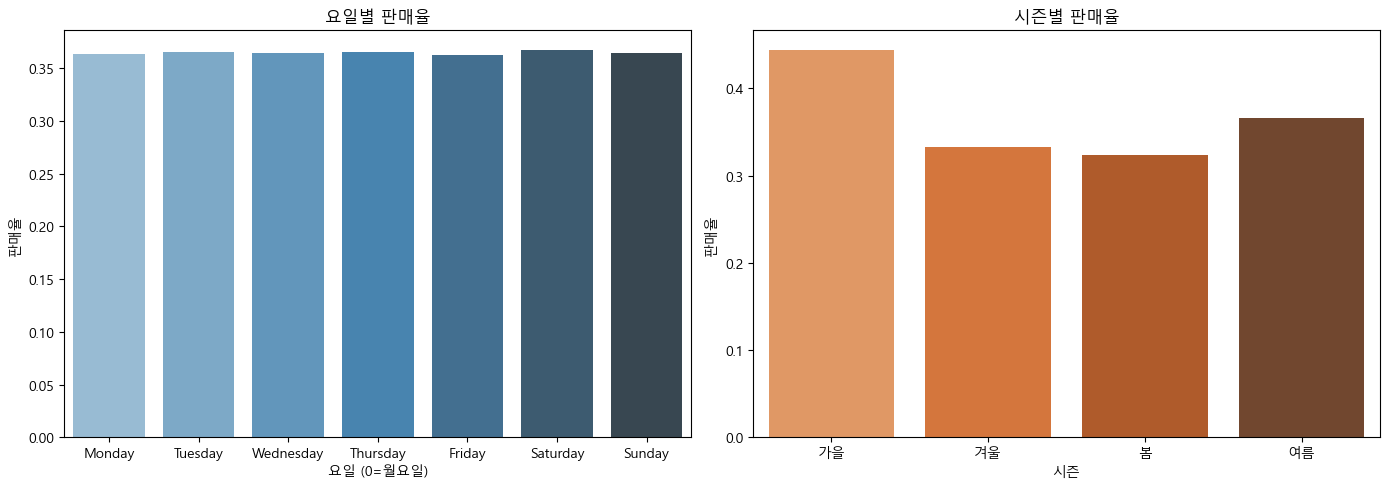

In [94]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=weekday_sale_rate, x='created_weekday', y='판매율', ax=ax[0], palette='Blues_d')
ax[0].set_title('요일별 판매율')
ax[0].set_xlabel('요일 (0=월요일)')
ax[0].set_ylabel('판매율')

sns.barplot(data=season_sale_rate, x='created_season', y='판매율', ax=ax[1], palette='Oranges_d')
ax[1].set_title('시즌별 판매율')
ax[1].set_xlabel('시즌')
ax[1].set_ylabel('판매율')

plt.tight_layout()
plt.show()

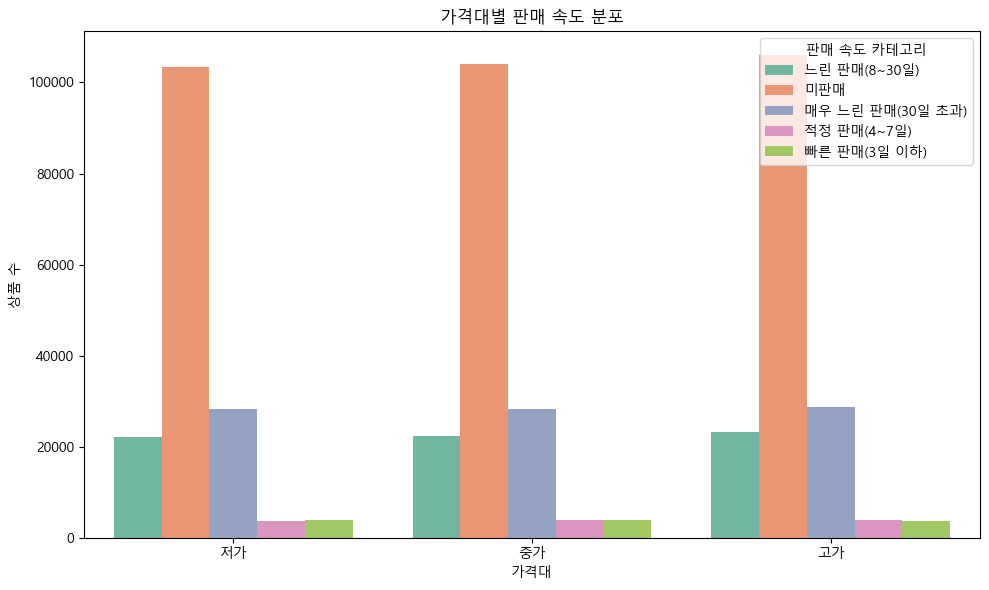

In [96]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='price_category', hue='sell_speed_category', palette='Set2')
plt.title('가격대별 판매 속도 분포')
plt.xlabel('가격대')
plt.ylabel('상품 수')
plt.legend(title='판매 속도 카테고리')
plt.tight_layout()
plt.show()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_33312\2876626055.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=brand_popularity, x='product_brand', y='고가 인기 상품 비율', palette='Purples_d')


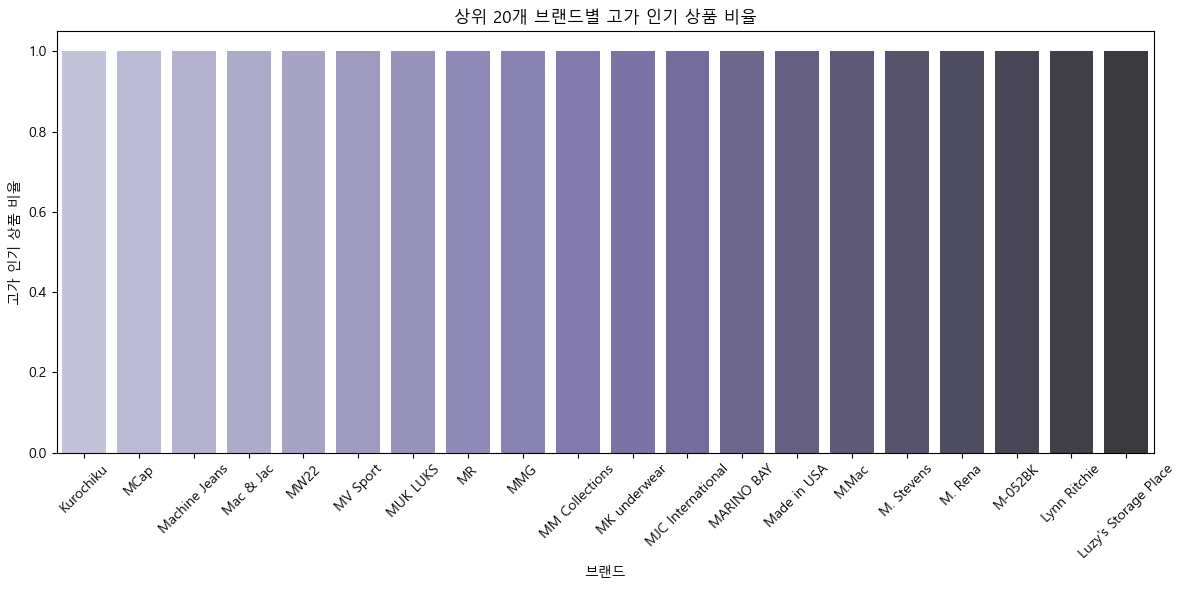

In [98]:
brand_popularity = df.groupby('product_brand').agg({
    'is_brand_top10_price': 'mean',
    'is_sold': 'mean'
}).rename(columns={'is_brand_top10_price': '고가 인기 상품 비율', 'is_sold': '판매율'}).reset_index()

brand_popularity = brand_popularity.sort_values('고가 인기 상품 비율', ascending=False).head(20)

plt.figure(figsize=(12, 6))
sns.barplot(data=brand_popularity, x='product_brand', y='고가 인기 상품 비율', palette='Purples_d')
plt.xticks(rotation=45)
plt.title('상위 20개 브랜드별 고가 인기 상품 비율')
plt.ylabel('고가 인기 상품 비율')
plt.xlabel('브랜드')
plt.tight_layout()
plt.show()